# Week 10 - Convolutional Neural Networks (CNNs) in Depth

**Course context:** Week 9 used `Conv2D`/`MaxPooling2D` without fully unpacking why they work. This week opens that box: what a convolution operation actually computes, why pooling helps, and how these pieces combine into real image classifiers - including data augmentation and batch normalization, two techniques that make CNNs train better in practice.

**A note on data:** the original exercises train on the real CIFAR-10 dataset, downloaded via `tensorflow.keras.datasets.cifar10` or `torchvision.datasets.CIFAR10`. Both download from hosts not reachable from every network (this notebook's environment included) - see Week 9 Day 1's note. This notebook uses small CIFAR-10-**shaped** synthetic (random) image data instead, so the code, architecture, and workflow are all identical to the real thing, but the actual accuracy numbers won't be meaningful (random pixels have no real patterns to learn) - swap in the real dataset for genuine results, following the commented-out real-dataset code included in each relevant cell.

**A note on TensorFlow + PyTorch together:** as flagged in Week 9, running heavy TensorFlow training and heavy PyTorch training in the *same* notebook kernel session can cause a crash on some systems due to a native library conflict. This notebook's single-forward-pass demo cells (Days 1-3) mix both frameworks safely, but the full training days (4-7) should each be run in their own fresh kernel if you hit a crash - restart the kernel between, say, Day 4 (TensorFlow) and Day 5 (PyTorch) if needed.

**How this notebook is organized:** one section per day, each with: what it covers -> why it matters for AI work -> code -> pitfalls.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import torch
torch.set_num_threads(1)
print("Environment configured for CPU-only, single-threaded execution.")

Environment configured for CPU-only, single-threaded execution.


## Day 1 - CNN Architecture Overview: Convolution + Pooling + Fully Connected

**What it covers:** Defining the same basic CNN "shape" in both TensorFlow/Keras and PyTorch: a convolutional layer, a pooling layer, then fully-connected layers to produce class predictions.

**Why it matters for AI work:** This three-part pattern (convolve -> pool -> repeat -> flatten -> dense) is the skeleton of nearly every image classification CNN, from the simplest toy example to production architectures. Once this shape is second nature, reading any new CNN architecture becomes "spot the variations on this pattern" rather than starting from scratch.

**Why convolution instead of just flattening the image into a plain neural network (Week 9's approach):**
- A plain fully-connected network treats every pixel independently and has to re-learn "what an edge looks like" separately for every possible position in the image - extremely wasteful.
- A convolutional layer learns a small set of filters (e.g. edge detectors) **once**, and slides them across the whole image - the same filter can detect an edge whether it appears in the top-left or bottom-right of the image. This "parameter sharing" is why CNNs need far fewer parameters than an equivalent fully-connected network for image data, and why they generalize better on images specifically.

**Pitfalls:**
- The original PyTorch version of this exercise passed `activation='relu'` directly to `nn.Conv2d(...)` - that's a Keras-ism; PyTorch's `Conv2d` has no `activation` argument at all. In PyTorch, activation functions are applied as a **separate step** in `forward()` (e.g. `F.relu(self.conv1(x))`), not baked into the layer itself. Fixed below.
- Manually computing the flattened size for the first `Linear` layer (`32 * 15 * 15` in the original) requires tracking exactly how convolution and pooling shrink the spatial dimensions - get this wrong and you get a shape-mismatch error at the first forward pass. Day 7 shows a more robust way to handle this (computing it dynamically instead of by hand).


In [2]:
import tensorflow as tf

# TensorFlow/Keras version
tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])
tf_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
tf_model.summary()
print("TensorFlow CNN model is ready.")

I0000 00:00:1784350877.829367     639 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784350877.867455     639 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784350879.233658     639 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,914 (3.52 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

TensorFlow CNN model is ready.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch version - note activation is applied in forward(), NOT passed to Conv2d
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)   # no activation argument here
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 15 * 15, 128)   # manually computed - see the pitfall note above
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(-1, 32 * 15 * 15)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

torch_model = SimpleCNN()
print(torch_model)

# Confirm the shape math with an actual forward pass
dummy_input = torch.randn(1, 3, 32, 32)
output = torch_model(dummy_input)
print(f"\nOutput shape for a batch of 1 32x32 RGB image: {output.shape} (10 class scores)")
print("PyTorch CNN model is ready.")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=7200, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Output shape for a batch of 1 32x32 RGB image: torch.Size([1, 10]) (10 class scores)
PyTorch CNN model is ready.


## Day 2 - What Convolution Actually Computes

**What it covers:** Applying hand-crafted convolution kernels (edge detection, blur) with SciPy to build direct intuition, then the same operation via TensorFlow's and PyTorch's `Conv2D`/`Conv2d` layers - including how kernel size and stride affect the output shape.

**Why it matters for AI work:** A convolution is just a small grid of numbers (the "kernel" or "filter") slid across an image, computing a weighted sum at each position. The edge-detection and blur kernels below are *hand-designed* examples of exactly the kind of pattern a CNN's `Conv2D` layer **learns automatically** from data during training - seeing the hand-crafted version first makes it much clearer what the learned filters are actually doing.

**Key parameters and their effect on output size:**
- **Kernel size** - bigger kernel = each output value "sees" a larger patch of the input (a bigger receptive field), but more parameters per filter
- **Stride** - how many pixels the kernel moves per step. Stride 2 skips every other position, roughly halving the output's height and width - a cheaper alternative to pooling (Day 3) for downsampling
- **Padding** (`'same'` in Keras, `padding=1` in PyTorch for a 3x3 kernel) - adds a border of zeros so the output stays the same spatial size as the input. Without padding (`'valid'`/`padding=0`), the output shrinks slightly every convolution - this compounds over many layers.

**Pitfalls:**
- Keras's `Conv2D` expects image tensors shaped `(batch, height, width, channels)` ("channels-last"); PyTorch's `Conv2d` expects `(batch, channels, height, width)` ("channels-first"). Mixing these up between frameworks is one of the most common cross-framework bugs - always double check tensor shape conventions when translating code between the two.
- The edge-detection kernel (`[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]`) sums to exactly 0 - this is intentional: a perfectly flat/uniform region of the image produces an output near 0 (no edge detected), while a region with sharp intensity changes produces a large positive or negative value (an edge detected).


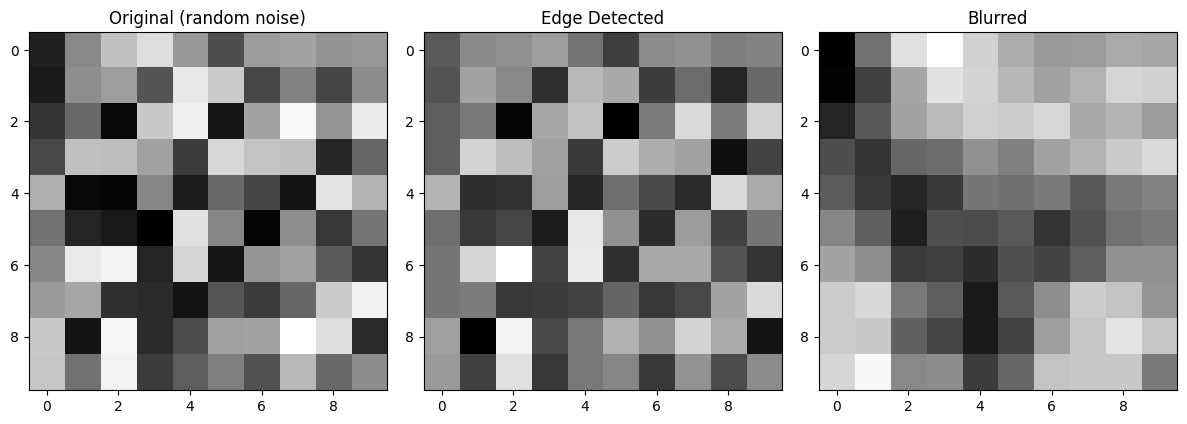

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

image = np.random.rand(10, 10)   # a small random "grayscale image" for illustration

edge_detection_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])
blur_kernel = np.ones((3, 3)) / 9   # simple averaging kernel

edge_detected_image = convolve(image, edge_detection_kernel)
blurred_image = convolve(image, blur_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original (random noise)")
axes[1].imshow(edge_detected_image, cmap="gray")
axes[1].set_title("Edge Detected")
axes[2].imshow(blurred_image, cmap="gray")
axes[2].set_title("Blurred")
plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf

image_tensor = tf.random.normal([1, 10, 10, 1])   # (batch, height, width, channels) - Keras convention

conv_layer = tf.keras.layers.Conv2D(filters=1, kernel_size=(3, 3), strides=(1, 1), padding="same")
output_tensor = conv_layer(image_tensor)

print(f"TensorFlow - Original Shape: {image_tensor.shape}")
print(f"TensorFlow - Output Shape (padding='same' keeps size): {output_tensor.shape}")

conv_layer_large_kernel = tf.keras.layers.Conv2D(filters=1, kernel_size=(5, 5), strides=(1, 1), padding="same")
output_large_kernel = conv_layer_large_kernel(image_tensor)
print(f"TensorFlow - Large (5x5) Kernel Output Shape: {output_large_kernel.shape}")

TensorFlow - Original Shape: (1, 10, 10, 1)
TensorFlow - Output Shape (padding='same' keeps size): (1, 10, 10, 1)
TensorFlow - Large (5x5) Kernel Output Shape: (1, 10, 10, 1)


In [4]:
import torch
import torch.nn as nn

image_tensor_pt = torch.randn(1, 1, 10, 10)   # (batch, channels, height, width) - PyTorch convention

conv_layer_pt = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1)
output_tensor_pt = conv_layer_pt(image_tensor_pt)

print(f"PyTorch - Original Shape: {image_tensor_pt.shape}")
print(f"PyTorch - Output Shape (padding=1 keeps size for a 3x3 kernel): {output_tensor_pt.shape}")

conv_layer_stride_2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)
output_stride_2 = conv_layer_stride_2(image_tensor_pt)
print(f"PyTorch - Stride 2 Output Shape (roughly half the size): {output_stride_2.shape}")

PyTorch - Original Shape: torch.Size([1, 1, 10, 10])
PyTorch - Output Shape (padding=1 keeps size for a 3x3 kernel): torch.Size([1, 1, 10, 10])
PyTorch - Stride 2 Output Shape (roughly half the size): torch.Size([1, 1, 5, 5])


## Day 3 - Pooling: Max vs Average, and Why It Helps

**What it covers:** Max pooling and average pooling, computed by hand-style with SciPy filters, then via Keras and PyTorch pooling layers.

**Why it matters for AI work:** Pooling shrinks the spatial size of feature maps between convolutional layers - this reduces computation, reduces the chance of overfitting (fewer parameters downstream), and adds a small amount of position-invariance (a feature slightly shifted in the image still gets detected).

**When to use what:**
- **Max pooling** - keeps the strongest activation in each region. The overwhelmingly common default in modern CNNs - tends to preserve the most salient features (the strongest edge/texture signal in a region).
- **Average pooling** - keeps the average activation in each region. Smoother, sometimes used at the very end of a network (global average pooling) as an alternative to `Flatten` + `Dense`, but less common mid-network than max pooling.

**Pitfalls:**
- The original PyTorch example has a typo bug: `nn.Conv2d(3, 32, kernal_size=3)` - `kernal_size` isn't a real argument (it's `kernel_size`), so this would raise a `TypeError` immediately. Fixed below. Worth knowing this exact class of bug is common - Python doesn't catch misspelled keyword arguments until runtime, unlike a misspelled variable name in some other languages.
- Pooling with no padding shrinks the feature map - stacking many pooling layers on a small input can eventually shrink the spatial dimensions to 0 or 1, at which point further convolutions have nothing meaningful left to work with. Worth sanity-checking your architecture's shapes on a small dummy input (as Day 7 does more rigorously) before training on real data.


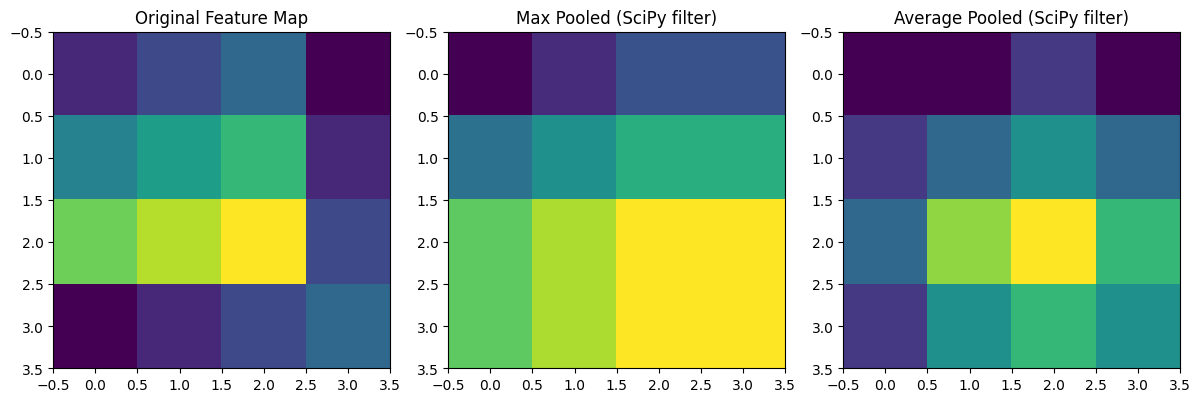

In [5]:
import numpy as np
from scipy.ndimage import maximum_filter, uniform_filter

feature_map = np.array([
    [1, 2, 3, 0],
    [4, 5, 6, 1],
    [7, 8, 9, 2],
    [0, 1, 2, 3],
])

max_pooled = maximum_filter(feature_map, size=2, mode="constant")
avg_pooled = uniform_filter(feature_map, size=2, mode="constant")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(feature_map, cmap="viridis")
axes[0].set_title("Original Feature Map")
axes[1].imshow(max_pooled, cmap="viridis")
axes[1].set_title("Max Pooled (SciPy filter)")
axes[2].imshow(avg_pooled, cmap="viridis")
axes[2].set_title("Average Pooled (SciPy filter)")
plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

input_tensor = tf.constant(feature_map.reshape(1, 4, 4, 1), dtype=tf.float32)

max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid")
max_pooled_tensor = max_pool(input_tensor)

avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding="valid")
avg_pooled_tensor = avg_pool(input_tensor)

print(f"TensorFlow Max Pooled:\n{tf.squeeze(max_pooled_tensor).numpy()}")
print(f"\nTensorFlow Average Pooled:\n{tf.squeeze(avg_pooled_tensor).numpy()}")

TensorFlow Max Pooled:
[[5. 6.]
 [8. 9.]]

TensorFlow Average Pooled:
[[3.  2.5]
 [4.  4. ]]


In [6]:
import torch
import torch.nn as nn

input_tensor_pt = torch.tensor(feature_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

max_pool_pt = nn.MaxPool2d(kernel_size=2, stride=2)
max_pooled_pt = max_pool_pt(input_tensor_pt)

avg_pool_pt = nn.AvgPool2d(kernel_size=2, stride=2)
avg_pooled_pt = avg_pool_pt(input_tensor_pt)

print(f"PyTorch Max Pooled:\n{max_pooled_pt.squeeze().numpy()}")
print(f"\nPyTorch Average Pooled:\n{avg_pooled_pt.squeeze().numpy()}")

# A small CNN combining conv + both pooling types, fixed (kernel_size, not the "kernal_size" typo)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.AvgPool2d(2, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        return x

sanity_check = SimpleCNN()(torch.randn(1, 3, 32, 32))
print(f"\nOutput shape after conv+pool+conv+pool on a 32x32 image: {sanity_check.shape}")

PyTorch Max Pooled:
[[5. 6.]
 [8. 9.]]

PyTorch Average Pooled:
[[3.  2.5]
 [4.  4. ]]

Output shape after conv+pool+conv+pool on a 32x32 image: torch.Size([1, 64, 6, 6])


## Day 4 - Training a Full CNN Classifier in Keras

**What it covers:** The complete training pipeline from Week 9 Day 5/7, applied to CIFAR-10-shaped (simulated) data - load, normalize, one-hot encode, build, train, evaluate, plot curves.

**Why it matters for AI work:** This is the "reference" full training pipeline for the rest of the week to compare against - Day 5 does the same task in PyTorch, Day 6 adds augmentation and batch norm to this same Keras structure.

**Reading the architecture:** two `Conv2D` + `MaxPooling2D` blocks (progressively more filters: 32 then 64, capturing increasingly complex patterns), then `Flatten` + `Dense` + `Dropout` + output layer - the same shape introduced in Week 9, just on slightly more complex (color, 32x32) images than MNIST.

**Pitfalls:**
- As with Week 9, `cifar10.load_data()` needs internet access to Google's dataset hosting - this notebook substitutes small synthetic CIFAR-10-shaped data (see the note at the top of this notebook). The real-dataset version is shown commented out below.
- Epochs and dataset size are trimmed significantly from the original (10 epochs on 50,000 images) for runtime reasons in this notebook - swap back up if you have more time/a GPU **and** the real dataset.


In [10]:
import numpy as np

# NOTE: the ORIGINAL exercise does this with:
#   from tensorflow.keras.datasets import cifar10
#   (X_train, y_train), (X_test, y_test) = cifar10.load_data()
# which needs internet access to Google's dataset hosting. Simulating CIFAR-10-shaped data instead.
np.random.seed(1)
X_train = np.random.randint(0, 256, size=(800, 32, 32, 3), dtype=np.uint8).astype("float32") / 255.0
y_train = np.random.randint(0, 10, size=(800, 1))
X_test = np.random.randint(0, 256, size=(200, 32, 32, 3), dtype=np.uint8).astype("float32") / 255.0
y_test = np.random.randint(0, 10, size=(200, 1))

from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training Data Shape: {X_train.shape}, Label Shapes: {y_train_cat.shape}")
print(f"Test Data Shape: {X_test.shape}, Label Shapes: {y_test_cat.shape}")

Training Data Shape: (800, 32, 32, 3), Label Shapes: (800, 10)
Test Data Shape: (200, 32, 32, 3), Label Shapes: (200, 10)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])
model.summary()

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

EPOCHS = 3   # original exercise used 10
history = model.fit(X_train, y_train_cat, epochs=EPOCHS, batch_size=64, validation_split=0.2)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1297 - loss: 2.2917

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.1297 - loss: 2.2917 - val_accuracy: 0.0938 - val_loss: 2.3034


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2188 - loss: 2.2916

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1150 - loss: 2.3065 


Test Accuracy: 0.1150


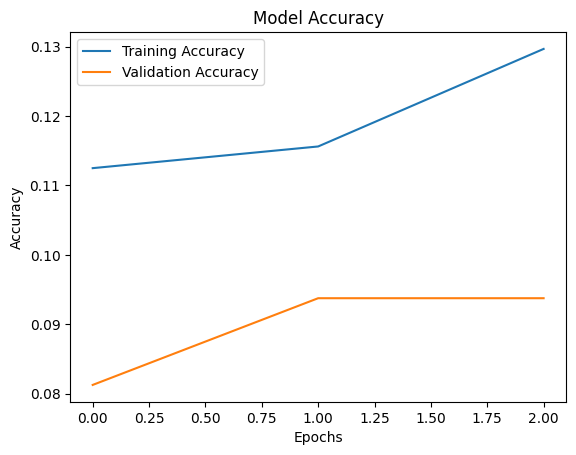

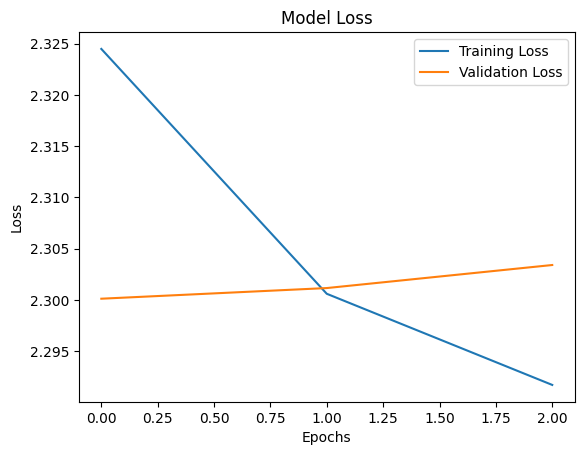

Reminder: trained on SIMULATED random data (see the note at the top of this notebook) -
accuracy near chance (10%) is EXPECTED here, not a bug.


In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
print("Reminder: trained on SIMULATED random data (see the note at the top of this notebook) -")
print("accuracy near chance (10%) is EXPECTED here, not a bug.")

## Day 5 - The Same Full Pipeline in PyTorch

**What it covers:** The PyTorch equivalent of Day 4 - a classic small CNN architecture (similar to the historic "LeNet" shape: conv -> pool -> conv -> pool -> fully connected layers), trained with a manual loop.

**Why it matters for AI work:** Direct side-by-side comparison with Day 4 reinforces that the *architecture and training concepts* are framework-independent - only the syntax for expressing them differs.

**Reading the architecture:** `Conv2d(3,6,5)` -> pool -> `Conv2d(6,16,5)` -> pool -> three `Linear` layers. The specific numbers (6, 16, 120, 84) come from the original LeNet-5 architecture, one of the earliest successful CNNs (1990s, digit recognition) - a small piece of deep learning history baked into a very common teaching example.

**Pitfalls:**
- `nn.Linear(16 * 5 * 5, 120)` - the `16 * 5 * 5` is the flattened size after two conv+pool blocks on a 32x32 input, computed by hand. Get the input image size or architecture wrong and this number needs recalculating - exactly the fragility Day 1 and Day 7 both flag, and exactly what Day 7's dynamic calculation avoids.
- This notebook uses a custom lightweight Dataset wrapping the synthetic CIFAR-10-shaped array (since real `datasets.CIFAR10(..., download=True)` needs unavailable internet access) - the training loop code itself is identical to what you'd use with the real dataset.


In [7]:
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# NOTE: the ORIGINAL exercise does this with:
#   train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
# which needs internet access. Wrapping the same synthetic CIFAR-10-shaped array from Day 4
# in a minimal custom Dataset instead - the DataLoader/training code below is identical either way.
class SyntheticCIFAR(Dataset):
    def __init__(self, n, seed):
        rng = np.random.RandomState(seed)
        self.images = rng.rand(n, 3, 32, 32).astype("float32") * 2 - 1   # already "normalized" to [-1, 1]
        self.labels = rng.randint(0, 10, size=n)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = SyntheticCIFAR(800, seed=2)
test_dataset = SyntheticCIFAR(200, seed=3)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training Data Size: {len(train_dataset)}")
print(f"Test Data Size: {len(test_dataset)}")

Training Data Size: 800
Test Data Size: 200


In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = CNN()
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

CNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [9]:
def train_model(model, train_loader, criterion, optimizer, epochs=3):   # original used 10
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

train_model(model, train_loader, criterion, optimizer)

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

evaluate_model(model, test_loader)
print("\nReminder: trained on SIMULATED random data - accuracy near chance (10%) is EXPECTED here.")

Epoch 1, Loss: 2.3031
Epoch 2, Loss: 2.3024


Epoch 3, Loss: 2.2997
Test Accuracy: 13.50%

Reminder: trained on SIMULATED random data - accuracy near chance (10%) is EXPECTED here.


## Day 6 - Data Augmentation and Batch Normalization

**What it covers:** Two techniques that meaningfully improve real CNN training: data augmentation (creating varied versions of training images on the fly) and batch normalization (normalizing activations between layers).

**Why it matters for AI work:** These two techniques, together with dropout (Week 9), are the standard toolkit for training CNNs that generalize well rather than overfitting the training set.

**How each technique helps:**
- **Data augmentation** (`ImageDataGenerator` - rotation, shifting, flipping) - artificially expands the effective size and variety of the training set. A model trained only on "upright, centered" images can fail on a slightly rotated or off-center real photo; augmentation teaches it to be robust to exactly these kinds of variation. This is essentially free extra training data.
- **Batch normalization** (`BatchNormalization`) - normalizes the activations flowing between layers (similar in spirit to Week 5-6's feature scaling, but applied *between* layers rather than just at the input). This tends to make training faster and more stable, and lets you use higher learning rates than you could otherwise.

**Pitfalls:**
- Augmentation should only be applied to the **training** set - the original exercise correctly evaluates on unmodified `(x_test, y_test)`, not augmented test data. Augmenting test data would make evaluation reflect a different, easier or harder distribution than what the model will actually face in production.
- `BatchNormalization` behaves differently during training vs inference (it uses batch statistics during training, and a running average during inference) - this is handled automatically by Keras, but it's the same underlying idea as PyTorch's `model.train()`/`model.eval()` distinction from Week 9 Day 6, now showing up for a new reason.
- The augmentation + batch norm + deeper architecture combination here is genuinely heavier to train than Day 4's plain CNN - the epoch count and dataset size are trimmed further in this notebook for that reason.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Reusing the synthetic CIFAR-10-shaped data from Day 4 (X_train/y_train_cat etc.)
# NOTE: the ORIGINAL exercise loads real CIFAR-10 via cifar10.load_data() - see the note
# at the top of this notebook for why that's substituted here.

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
datagen.fit(X_train)
print("Data augmentation generator configured (rotation, shift, horizontal flip).")

Data augmentation generator configured (rotation, shift, horizontal flip).


In [12]:
def create_model():
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))

    model.add(layers.Conv2D(32, (3, 3), activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))
    return model

augmented_model = create_model()
augmented_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
augmented_model.summary()

EPOCHS_AUG = 3   # original exercise used 20 on the full 50,000-image dataset
history_aug = augmented_model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=EPOCHS_AUG,
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=max(1, X_train.shape[0] // 64),
)

test_loss_aug, test_accuracy_aug = augmented_model.evaluate(X_test, y_test_cat, verbose=2)
print(f"Test Accuracy: {test_accuracy_aug:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,450 (2.34 MB)

 Trainable params: 612,746 (2.34 MB)

 Non-trainable params: 704 (2.75 KB)

...

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1176 - loss: 3.4064

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1141 - loss: 3.4338

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.1141 - loss: 3.4338 - val_accuracy: 0.1150 - val_loss: 2.3181


7/7 - 0s - 10ms/step - accuracy: 0.1150 - loss: 2.3181


Test Accuracy: 0.1150


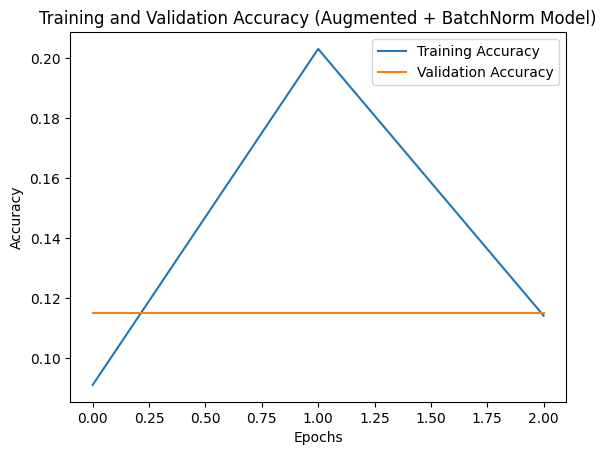

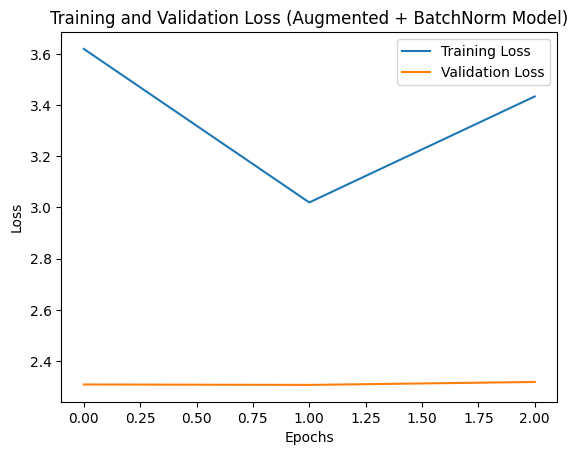

In [13]:
plt.plot(history_aug.history["accuracy"], label="Training Accuracy")
plt.plot(history_aug.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Augmented + BatchNorm Model)")
plt.legend()
plt.show()

plt.plot(history_aug.history["loss"], label="Training Loss")
plt.plot(history_aug.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Augmented + BatchNorm Model)")
plt.legend()
plt.show()

## Day 7 - Mini Project: An Enhanced PyTorch CNN with Batch Norm and Dynamic Shape Calculation

**What it covers:** A more robust PyTorch CNN combining batch normalization, dropout, and data augmentation transforms - plus a technique for computing the flatten size **dynamically** instead of by hand, fixing the fragility flagged in Day 1 and Day 5.

**Why it matters for AI work:** The dynamic shape calculation pattern (`_calculate_conv_output`) is a genuinely useful engineering habit: run a dummy input through the convolutional layers once, at construction time, and read off the resulting shape - instead of hand-computing it and having it silently become wrong the moment you change the input size or add a layer.

**How the dynamic calculation works:**
```
dummy_input = torch.zeros(1, 3, 32, 32)          # a fake single image, right shape
with torch.no_grad():                              # no need to track gradients for this
    output = <run it through the conv/pool layers>
self.conv_output_size = output.numel()              # total number of values = the flatten size
```
This runs once when the model is constructed, and the result is reused for the real `Linear` layer's input size - the model now automatically adapts if you change the input resolution or add another conv/pool block, without manual recalculation.

**Pitfalls:**
- `torch.no_grad()` around the dummy forward pass matters - without it, this "just checking the shape" operation would unnecessarily build a computation graph for gradients you're never going to use.
- Data augmentation transforms (`RandomHorizontalFlip`, `RandomCrop`) are applied via `transform_train` only - `transform_test` deliberately excludes them, same reasoning as Day 6's pitfall about not augmenting test data.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

# Data augmentation is normally expressed via torchvision transforms on real image data
# (RandomHorizontalFlip, RandomCrop) - since this notebook uses synthetic array data instead
# of real images (see the note at the top), we apply the same AUGMENTATION IDEA manually:
# random horizontal flips, computed directly on the array.
class AugmentedSyntheticCIFAR(Dataset):
    def __init__(self, n, seed, augment=True):
        rng = np.random.RandomState(seed)
        self.images = rng.rand(n, 3, 32, 32).astype("float32") * 2 - 1
        self.labels = rng.randint(0, 10, size=n)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].copy()
        if self.augment and np.random.rand() > 0.5:
            img = img[:, :, ::-1].copy()   # random horizontal flip
        return torch.tensor(img), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = AugmentedSyntheticCIFAR(800, seed=4, augment=True)
test_dataset = AugmentedSyntheticCIFAR(200, seed=5, augment=False)   # no augmentation at test time

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training Data Size: {len(train_dataset)}")
print(f"Test Data Size: {len(test_dataset)}")

Training Data Size: 800
Test Data Size: 200


In [8]:
class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self._calculate_conv_output()   # compute the flatten size dynamically - see markdown above

        self.fc1 = nn.Linear(self.conv_output_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def _calculate_conv_output(self):
        dummy_input = torch.zeros(1, 3, 32, 32)
        with torch.no_grad():
            output = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(dummy_input)))))))
        self.conv_output_size = output.numel()

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = EnhancedCNN()
print(model)
print(f"\nDynamically computed flatten size: {model.conv_output_size}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EnhancedCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Dynamically computed flatten size: 2304


In [9]:
training_loss = []

def train_model(model, train_loader, criterion, optimizer, epochs=3):   # original used 20
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        training_loss.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

train_model(model, train_loader, criterion, optimizer)

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

evaluate_model(model, test_loader)

Epoch 1, Loss: 2.3698


Epoch 2, Loss: 2.3315


Epoch 3, Loss: 2.3043
Test Accuracy: 9.00%


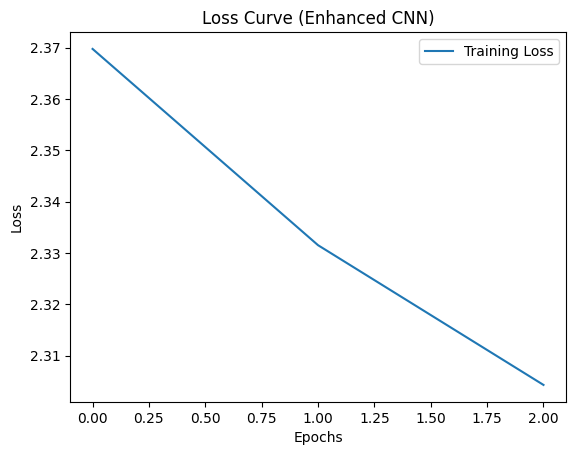

Reminder: trained on SIMULATED random data - use the real CIFAR-10 dataset for genuine results.


In [10]:
plt.plot(training_loss, label="Training Loss")
plt.title("Loss Curve (Enhanced CNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
print("Reminder: trained on SIMULATED random data - use the real CIFAR-10 dataset for genuine results.")

## Week 10 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | CNN architecture skeleton | Every CNN you'll build or read |
| 2 | What convolution computes | Understanding what a trained filter "sees" |
| 3 | Max vs average pooling | Downsampling choices in any CNN |
| 4 | Full Keras training pipeline | The reference pipeline for the rest of this week |
| 5 | Full PyTorch training pipeline | Same pipeline, PyTorch syntax |
| 6 | Data augmentation, batch norm (Keras) | Standard tools for training CNNs that generalize |
| 7 | Dynamic shape calculation, augmentation (PyTorch) | Robust architecture code, avoiding hand-computed bugs |

**Before moving to Week 11:** you should be able to sketch a basic CNN architecture (conv/pool blocks + dense layers) for a new image task without looking up the pattern, and explain in one sentence why augmentation and batch norm each help. Week 11 shifts from images to sequences - RNNs, LSTMs, and GRUs for text and time-series data, where the core challenge (remembering earlier context) is completely different from CNNs' spatial pattern-matching.
